# 2. Variables Aleatorias

## 2.1 Definiciones Básicas

Una variable aleatoria $X:\Omega \rightarrow \mathbb{R}$ definida en un espacio de probabilidad $(\Omega, \mathcal{F}, \mathbb{P})$ satisface la siguiente propiedad: 
\begin{align}
X^{-1}(\infty, x]\in \mathcal{F}, x\in \mathbb{R}.
\end{align}

De este modo se induce de manera natural una medida de probabilidad en el espacio medible $(\mathbb{R}, \mathcal{B}(\mathbb{R}))$, del modo siguiente:
\begin{align}
F(x):=\mathbb{P}(X^{-1}(\infty, x]), x \in \mathbb{R}. 
\end{align}

En el caso de variables aleatorias de tipo discreto, es más común describir su distribución a partir de su función puntual o de masa, definida como:

\begin{align}
f(x)=\mathbb{P}(X=x), x\in \mathcal{R}an(X)
\end{align}

### En el caso continuo la correspondeinte función es la densidad, la cual se obtiene también a partir de la distrbución acumulado, de acuerdo con:

\begin{align}
f(x)=\frac{dF(x)}{dx}.
\end{align}

### En Python se usa el módulo Statistical functions (scipy.stats)
 https://docs.scipy.org/doc/scipy/reference/stats.html

### Para la función de densidad/probabilidad (PDF): 

### $\bullet$ rv_discrete.pmf(k, *args)

### $\bullet$ rv_continuous.pdf(q, *args)

### Para la función de distribución acumulada (CDF):

### $\bullet$ rv_continuous.cdf(x, *args)

### $\bullet$ rv_discrete.cdf(k, *args) 

### Para percentiles (PPF):

### $\bullet$ rv_continuous.ppf(x, *args)

### $\bullet$ rv_discrete.ppf(x, *args)

<img src=res.png>

## 2.2 Percentiles, Cuantiles e Intercuantiles

Los percentiles son medidas de posición no central, los cuales permiten conocer otros puntos característicos de la distribución. El cuantil de orden $p$ de una distribución (con $0 < p < 1$) es el valor $x_p$ de la variable $X$, tal que 
\begin{align}
p=P(X\leq x_p)
\end{align}

Algunos percentiles comunes incluyen:

El cuantil de orden 0.25 es el primer cuartil (Q1) o el percentil 25 (P25).

El cuantil de orden 0.5 es la mediana (Q2) o el percentil 50 (P50).

El cuantil de orden 0.75 es el tercer cuartil (Q3) o el percentil 75 (P75).

In [1]:
from scipy.stats import expon
import pandas as pd

lam = 0.5
probabilidades = [0.25, 0.50, 0.75]  

cuantiles = expon.ppf(probabilidades, scale=1/lam)

dfqpois=pd.DataFrame({'cuantil': [0.25, 0.5, 0.75], 'valor': cuantiles})
dfqpois

,cuantil,valor
0,0.25,0.575364
1,0.50,1.386294
2,0.75,2.772589


In [5]:
expon.ppf(0.2, scale=1/lam)

0.44628710262841953

$\textbf{Ejercicio}$ realizar el cálculo análogo pra la normal(0, 1).

### El rango intercuartílico (IQR) representa una medida de dispersión estadística se define como la diferencia entre el tercer cuartil (Q3) y el primer cuartil (Q1). De este modo, el IQR abarca el rango medio del conjunto de datos, excluyendo los valores extremos en ambos extremos.

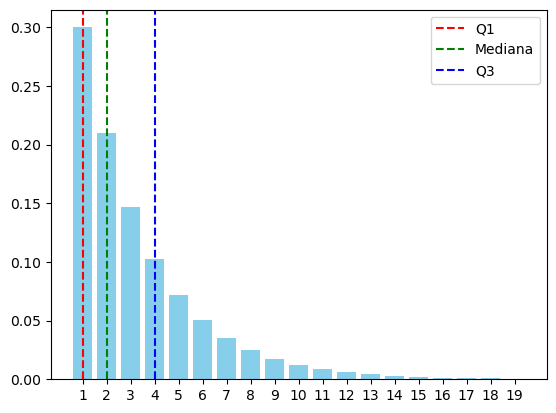

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import geom

p = 0.3
x = np.arange(1, 20)

probabilidades = geom.pmf(x, p)

q1 = geom.ppf(0.25, p)
q2 = geom.ppf(0.50, p)  
q3 = geom.ppf(0.75, p)

plt.bar(x, probabilidades, color='skyblue')
plt.axvline(x=q1, color='red', linestyle='--', label='Q1')
plt.axvline(x=q2, color='green', linestyle='--', label='Mediana')
plt.axvline(x=q3, color='blue', linestyle='--', label='Q3')
plt.legend()
plt.xticks(x)
plt.show()

In [7]:
IQ=q3-q1
IQ

3.0

### $\textbf{Ejercicio}$ Realizar lo análogo para la distribución Poisson.

## 2.3 Distribuciones con nombre

### $\textbf{Ejemplo 2.2.1}$ Iniciemos con una v.a. discreta que toma un número finito de valores, por ejemplo, $\{0,1,2,3\}$, con probabilidades $\{0.25, 0.35, 0.2, 0.2\}$, respectivamente. Grafiquemos su función de distribución acumulada.

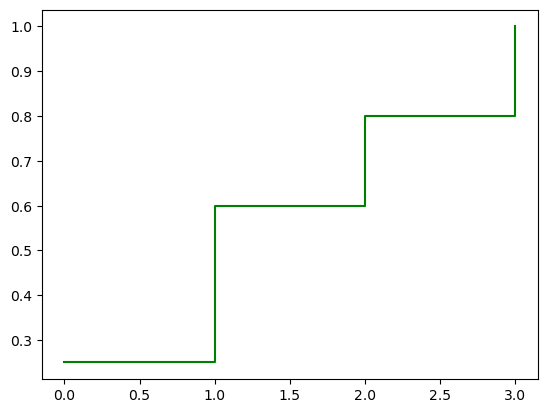

In [4]:
valores = [0, 1, 2, 3]
probabilidades = [0.25, 0.35, 0.2, 0.2]

probabilidades_acumuladas = np.cumsum(probabilidades)

plt.step(valores, probabilidades_acumuladas, color='green', where='post')
plt.show()

### $\textbf{Ejemplo 2.2.2}$ Consideremos una empresa que decide abrir puestos para contratación en algunos de sus sectores, para ello lanza una convocatoria y en una fecha especifica se llevan a cabo una evaluación a los candidatos. En base a la experiencia en contrataciones del sector se ha observado que el 30 % aprueba la entrevista. Suponga que el número de candidatos registrados para el puesto en total son 30 y cada uno de ellos se evalua de manera personal. Si la empresa requiere más de 5 candidatos para cubrir sus necesidades, determinar la probabilidad de que se logre satisfacer los requerimentos de la empresa.

In [9]:
from scipy.stats import binom 

n = 30
p = 0.3

valores = list(range(n + 1))  
masa = [round(binom.pmf(r, n, p),4) for r in valores] 

dfbin=pd.DataFrame({'valores': valores, 'masa': masa})
dfbin

,valores,masa
0,0,0.0000
1,1,0.0003
2,2,0.0018
3,3,0.0072
4,4,0.0208
5,5,0.0464
6,6,0.0829
7,7,0.1219
8,8,0.1501
9,9,0.1573


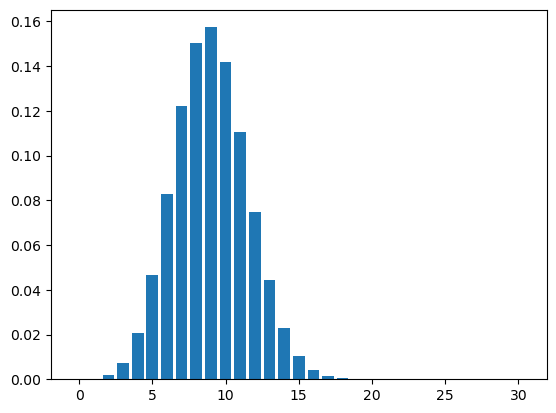

In [10]:
plt.bar(valores, masa) 
plt.show()

In [7]:
binom.stats(n, p, moments='mvsk')

(9.0, 6.3, 0.15936381457791915, -0.041269841269841234)

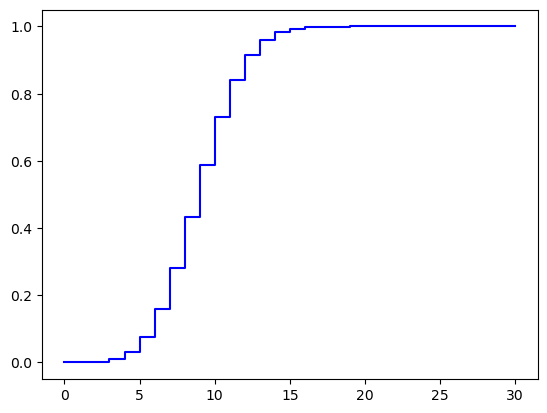

In [8]:
cdf_valores = binom.cdf(valores, n, p)

plt.step(valores, cdf_valores, color='blue', where='post')
plt.show()

### Solución

In [11]:
sum(dfbin.masa[dfbin.valores>5])

0.9234

In [12]:
1 - binom.cdf(5, n, p)

0.9234052479924494

In [13]:
binom.sf(5, n, p)

0.9234052479924494

### Suponga que la evaluación consta de 10 preguntas y la probabilidad de que un candidato conteste cada una de las preguntas de forma acertada es $0.4$. ¿Cuántas entrevistas se tienen que llevar a cabo para generar el primer contrato?

In [14]:
probabilidad_aprobación=binom.sf(5 , 10, 0.4) #=1-binom.cdf(5 , 10, 0.4)
geom.mean(probabilidad_aprobación)

6.015449445123392

### Ejercicio: Elaborar un gráfico para la distribución acumulada de la distribución geométrica. Elaborar un gráfico de barras para la pmf. Indicar el tipo de asimetría y kurtosis

### $\textbf{Ejemplo 2.2.3}$ Considere una sala de emergencias de un hospital a la cual en promedio asisten 10 pacientes por hora. Se ha observado que el 60 % de los pacientes son hospitalizados. En promedio cuantos pacientes en un periodo de una hora son hospitalizados.

In [15]:
from scipy.stats import poisson
mu=10
n=20
valores = list(range(n+1)) 
dist = [poisson.pmf(r, mu) for r in valores] 
dfpois=pd.DataFrame({'masa':dist}, index=valores)
dfpois

,masa
0,0.000045
1,0.000454
2,0.002270
3,0.007567
4,0.018917
5,0.037833
6,0.063055
7,0.090079
8,0.112599
9,0.125110


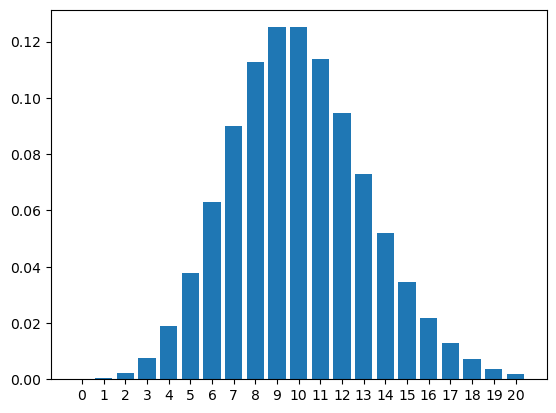

In [16]:
plt.bar(valores, dist)
plt.xticks(valores)
plt.show()

### Solución:

In [17]:
poisson.mean(6)

6.0

### $\textbf{Ejemplo 2.2.4}$ Suponga que $X$ representa las medidas de cierto artículo de precisión. Una compañía se encarga de producir dichos artículos los cuales generan utilidade si cumple con $10\leq X\leq 12$, en caso contrario genera distintas perdidas. De acuerdo a la siguiente función:
\begin{align}
U=\left\{ \begin{array}{lcc} 10 & si & 10 \leq X \leq 12 \\ \\ -3 & si & X < 10 \\ \\ -2 & si & X > 12 \end{array} \right.
\end{align}

### Suponga que $X$ es una variable aleatoria Normal con $\mu=11$ y $\sigma^2=1$. Calcular la utilidad esperada.

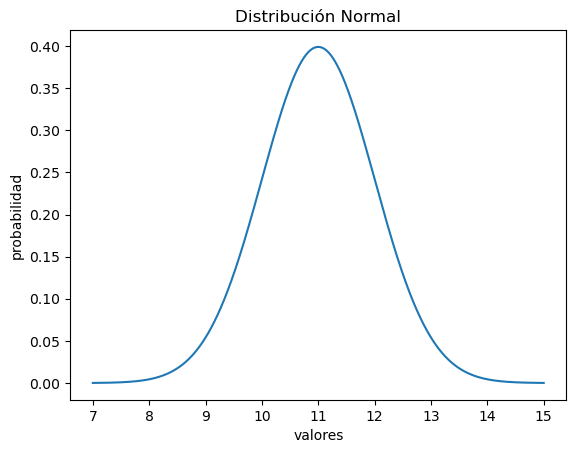

In [20]:
from scipy.stats import norm
mu= 11 
sigma = 1 

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, 11, 1) 

plt.plot(x, y)
plt.title('Distribución Normal')
plt.ylabel('probabilidad')
plt.xlabel('valores')
plt.show()

In [13]:
norm.stats(11, 1, moments='mvsk')

(11.0, 1.0, 0.0, 0.0)

### SOLUCIÓN

In [21]:
10*(norm.cdf(12, 11, 1)-norm.cdf(10, 11, 1))-3*norm.cdf(10, 11, 1)-2*(1-norm.cdf(12, 11, 1))

6.033618651713573

### $\textbf{Ejemplo 2.2.5}$ Suponga que un análista es contratado por servicio de atención al cliente y está interesado en modelar el tiempo entre arribos (inter-arribos) de clientes al servicio. Supongamos que la tasa de interarribos es 0.1 clientes por minuto.

### A) ¿Cuál es la probabilidad de que el próximo cliente llegue en menos de 5 minutos?

### B) ¿Cuál es la probabilidad de que el próximo cliente llegue después de 10 minutos desde el último arribo?

### Ejercicio: Graficar su función de densidad y su función de distribución acumulada.

### Solución:

### $\textbf{Ejemplo 2.2.5}$ Supongamos que se tiene un conjunto de activos financieros, y estamos interesados en modelar conjuntamente las distribuciones de rendimientos de varios de esos activos. 

In [23]:
!pip install yfinance

     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
      --------------------------------------- 0.1/3.0 MB 4.1 MB/s eta 0:00:01
     -- ------------------------------------- 0.2/3.0 MB 3.5 MB/s eta 0:00:01
     --------- ------------------------------ 0.7/3.0 MB 5.7 MB/s eta 0:00:01
     ---------------------- ----------------- 1.7/3.0 MB 10.1 MB/s eta 0:00:01
     ---------------------------------------  3.0/3.0 MB 14.8 MB/s eta 0:00:01
     ---------------------------------------  3.0/3.0 MB 14.8 MB/s eta 0:00:01
     ---------------------------------------- 3.0/3.0 MB 11.4 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1

In [24]:
import yfinance as yf
AMZN=yf.download('AMZN', start = '2024-01-01', end='2024-12-31')
AMZN

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,
2024-01-02,149.929993,152.380005,148.389999,151.539993,47339400
2024-01-03,148.470001,151.050003,148.330002,149.199997,49425500
2024-01-04,144.570007,147.380005,144.050003,145.589996,56039800
2024-01-05,145.240005,146.589996,144.529999,144.690002,45124800
2024-01-08,149.100006,149.399994,146.149994,146.740005,46757100
...,...,...,...,...,...
2024-12-23,225.059998,226.880005,223.899994,225.009995,28070000
2024-12-24,229.050003,229.139999,226.130005,226.940002,15007500


[*********************100%***********************]  2 of 2 completed


Ticker      AAPL      MSFT
Ticker                    
AAPL    1.000000  0.471803
MSFT    0.471803  1.000000


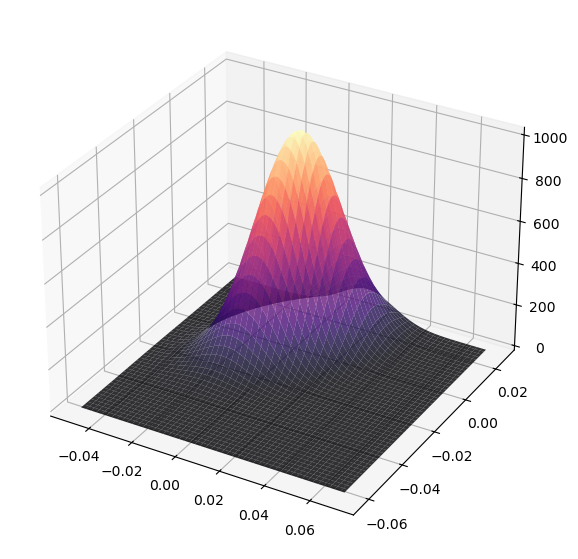

In [26]:
from scipy.stats import multivariate_normal

tickers = ["MSFT", "AAPL"]
data = yf.download(tickers, start="2024-01-01", end="2024-12-31")
precios=data['Close']
returns = np.log(precios / precios.shift(1)).dropna()

mu = returns.mean().values
cov_matrix = returns.cov().values
correlation_matrix = returns.corr()
print(correlation_matrix)
rv = multivariate_normal(mu, cov_matrix)

x, y = np.meshgrid(np.linspace(returns.iloc[:, 0].min(), returns.iloc[:, 0].max(), 200),
                   np.linspace(returns.iloc[:, 1].min(), returns.iloc[:, 1].max(), 200))
par = np.dstack((x, y))

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, rv.pdf(par), cmap='magma', edgecolor='none', alpha=0.8)
plt.show()

### ¿Cuál es la probabilidad de que los rendimientos del portafolio se encuentren por debajo del valor promedio?

In [27]:
rv.cdf(mu)

0.3281983642629219

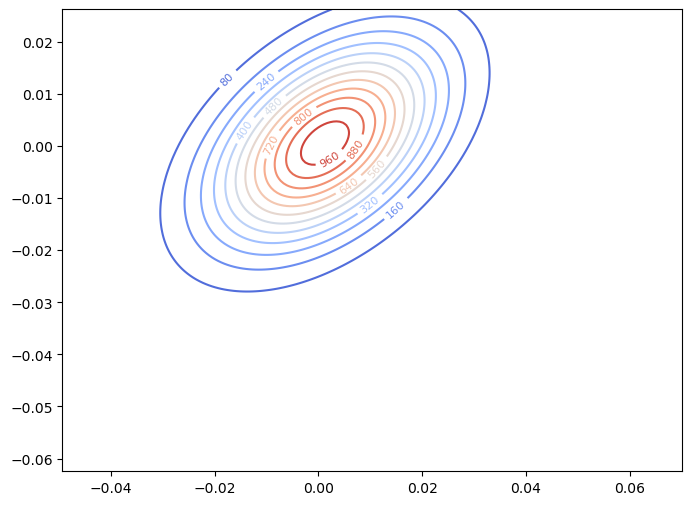

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
contour_lines = ax.contour(x, y, rv.pdf(par), cmap='coolwarm', levels=15)
ax.clabel(contour_lines, inline=True, fontsize=8)
plt.show()

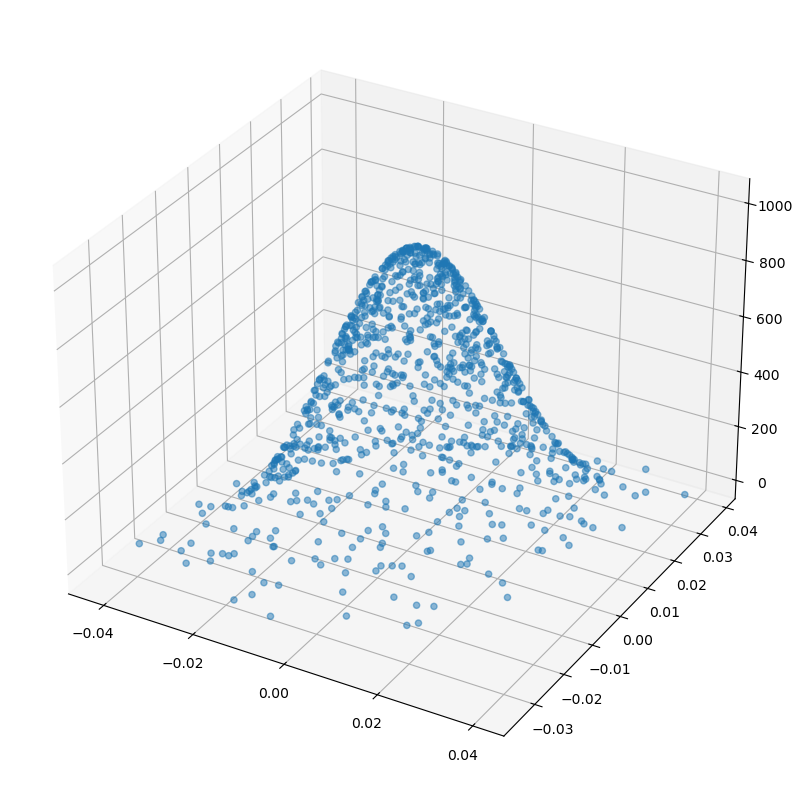

In [30]:
muestra = rv.rvs(size=1000)

fig = plt.figure(figsize=(10, 15))
ax=fig.add_subplot(projection='3d')
ax.scatter(muestra[:, 0], muestra[:, 1], rv.pdf(muestra), alpha=0.5)
plt.show()